In [85]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#For ignoring warning
import warnings
warnings.filterwarnings("ignore")

In [86]:
df=pd.read_csv('../content/drive/MyDrive/Breast Cancer/Breast_Cancer.csv')
df

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4019,62,Other,Married,T1,N1,IIA,Moderately differentiated,2,Regional,9,Positive,Positive,1,1,49,Alive
4020,56,White,Divorced,T2,N2,IIIA,Moderately differentiated,2,Regional,46,Positive,Positive,14,8,69,Alive
4021,68,White,Married,T2,N1,IIB,Moderately differentiated,2,Regional,22,Positive,Negative,11,3,69,Alive
4022,58,Black,Divorced,T2,N1,IIB,Moderately differentiated,2,Regional,44,Positive,Positive,11,1,72,Alive


In [87]:
df.shape

(4024, 16)

In [88]:
#Checking for Duplicates
df.duplicated().sum()

np.int64(1)

In [89]:
#Removing Duplicates
df=df.drop_duplicates()

In [90]:
#Checking for null values
df.isnull().sum()

,0
Age,0
Race,0
Marital Status,0
T Stage,0
N Stage,0
6th Stage,0
differentiate,0
Grade,0
A Stage,0
Tumor Size,0


In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4023 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     4023 non-null   int64 
 1   Race                    4023 non-null   object
 2   Marital Status          4023 non-null   object
 3   T Stage                 4023 non-null   object
 4   N Stage                 4023 non-null   object
 5   6th Stage               4023 non-null   object
 6   differentiate           4023 non-null   object
 7   Grade                   4023 non-null   object
 8   A Stage                 4023 non-null   object
 9   Tumor Size              4023 non-null   int64 
 10  Estrogen Status         4023 non-null   object
 11  Progesterone Status     4023 non-null   object
 12  Regional Node Examined  4023 non-null   int64 
 13  Reginol Node Positive   4023 non-null   int64 
 14  Survival Months         4023 non-null   int64 
 15  Status   

In [92]:
df.describe()

,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months
count,4023.000000,4023.000000,4023.000000,4023.000000,4023.000000
mean,53.969923,30.477007,14.358439,4.158837,71.301765
std,8.963118,21.121253,8.100241,5.109724,22.923009
min,30.000000,1.000000,1.000000,1.000000,1.000000
25%,47.000000,16.000000,9.000000,1.000000,56.000000
50%,54.000000,25.000000,14.000000,2.000000,73.000000
75%,61.000000,38.000000,19.000000,5.000000,90.000000
max,69.000000,140.000000,61.000000,46.000000,107.000000


In [93]:
from sklearn import preprocessing
le=preprocessing.LabelEncoder()

# Get all object type columns that still need encoding
object_cols = df.select_dtypes(include='object').columns

# Apply LabelEncoder to each identified object type column
for col in object_cols:
    df[col]=le.fit_transform(df[col])

# Display the updated info to verify transformations
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4023 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Age                     4023 non-null   int64
 1   Race                    4023 non-null   int64
 2   Marital Status          4023 non-null   int64
 3   T Stage                 4023 non-null   int64
 4   N Stage                 4023 non-null   int64
 5   6th Stage               4023 non-null   int64
 6   differentiate           4023 non-null   int64
 7   Grade                   4023 non-null   int64
 8   A Stage                 4023 non-null   int64
 9   Tumor Size              4023 non-null   int64
 10  Estrogen Status         4023 non-null   int64
 11  Progesterone Status     4023 non-null   int64
 12  Regional Node Examined  4023 non-null   int64
 13  Reginol Node Positive   4023 non-null   int64
 14  Survival Months         4023 non-null   int64
 15  Status                  40

In [94]:
df

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,2,1,0,0,0,1,3,1,4,1,1,24,1,60,0
1,50,2,1,1,1,2,0,2,1,35,1,1,14,5,62,0
2,58,2,0,2,2,4,0,2,1,63,1,1,14,7,75,0
3,58,2,1,0,0,0,1,3,1,18,1,1,2,1,84,0
4,47,2,1,1,0,1,1,3,1,41,1,1,3,1,50,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4019,62,1,1,0,0,0,0,2,1,9,1,1,1,1,49,0
4020,56,2,0,1,1,2,0,2,1,46,1,1,14,8,69,0
4021,68,2,1,1,0,1,0,2,1,22,1,0,11,3,69,0
4022,58,0,0,1,0,1,0,2,1,44,1,1,11,1,72,0


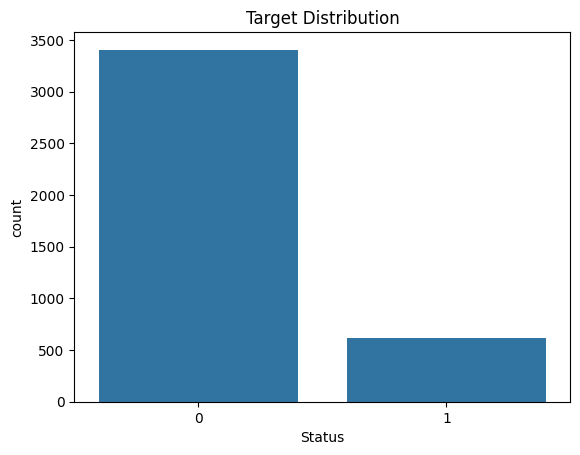

In [95]:
#Let's check the distributaion of Target variable.
sns.countplot(x='Status', data=df)
plt.title('Target Distribution');

In [96]:
df['Status'].value_counts()

,count
Status,
0,3407
1,616


In [97]:
# function for plotting
def plot(col, df=df):
    return df.groupby(col)['Status'].value_counts(normalize=True).unstack().plot(kind='bar', figsize=(8,5))

<Axes: xlabel='Age'>

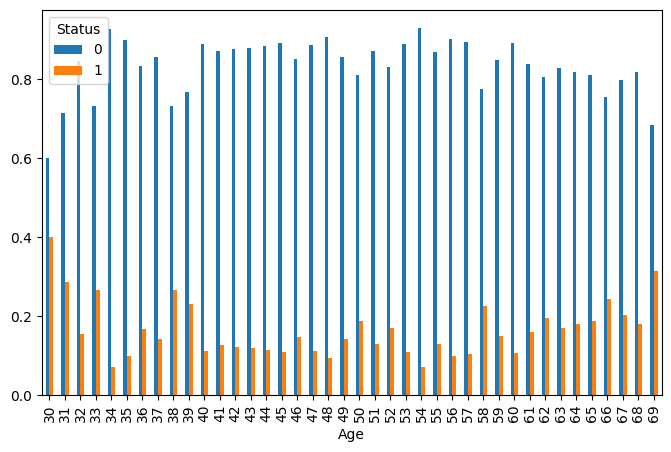

In [98]:
plot('Age')

<Axes: xlabel='Race'>

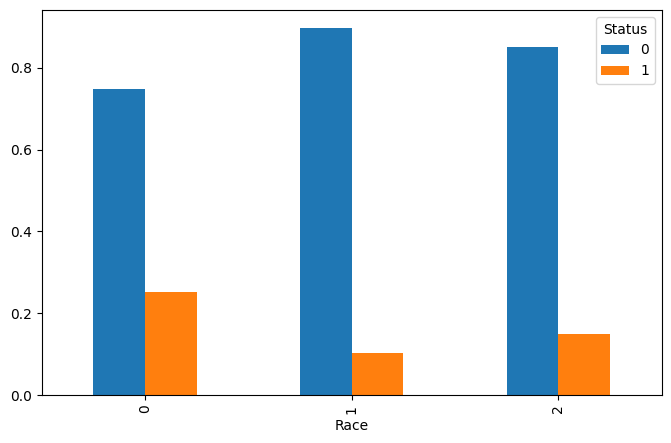

In [99]:
plot('Race')

<Axes: xlabel='Marital Status'>

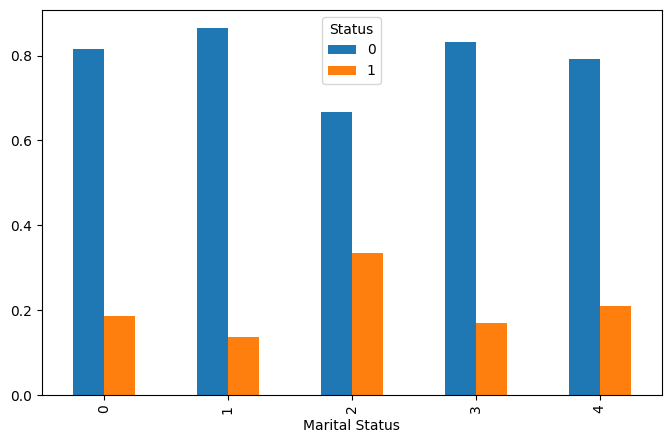

In [100]:
plot('Marital Status')

<Axes: xlabel='N Stage'>

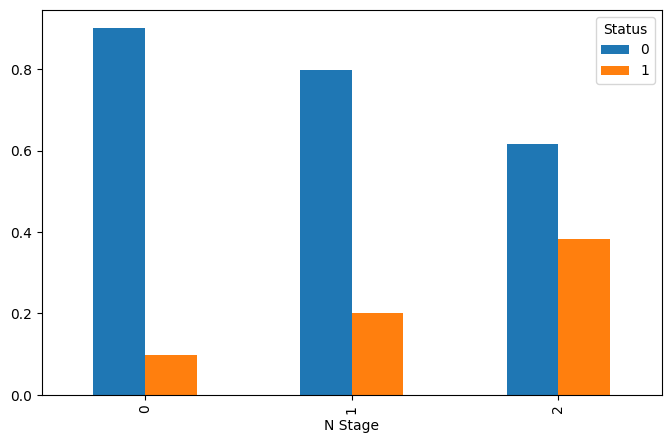

In [101]:
plot('N Stage')

<Axes: xlabel='6th Stage'>

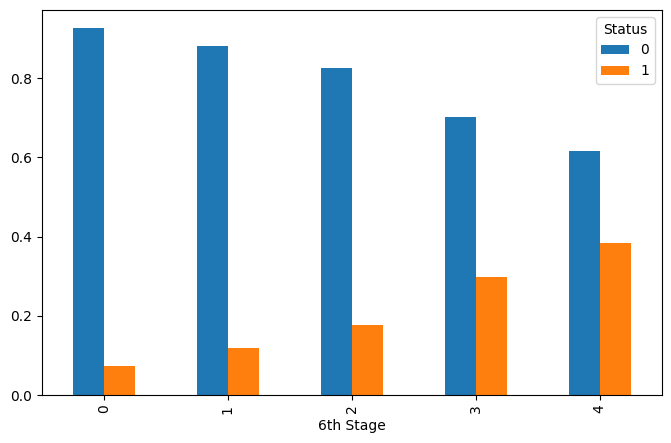

In [102]:
plot('6th Stage')

<Axes: xlabel='differentiate'>

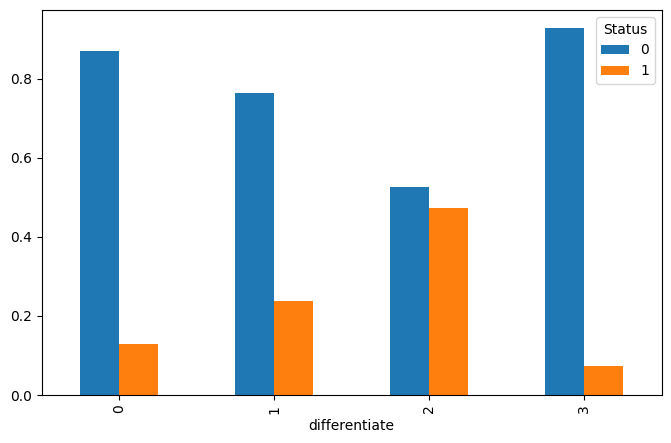

In [103]:
plot('differentiate')

<Axes: xlabel='Grade'>

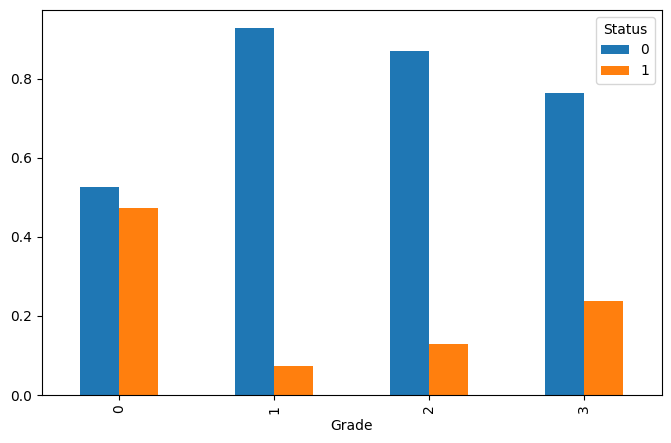

In [104]:
plot('Grade')

<Axes: xlabel='A Stage'>

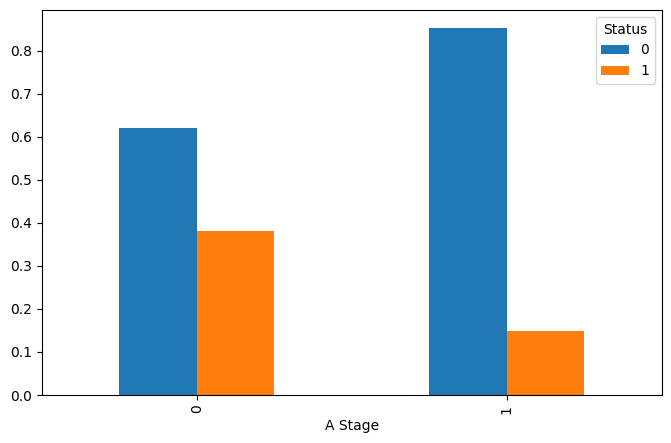

In [105]:
plot('A Stage')

<Axes: xlabel='Tumor Size'>

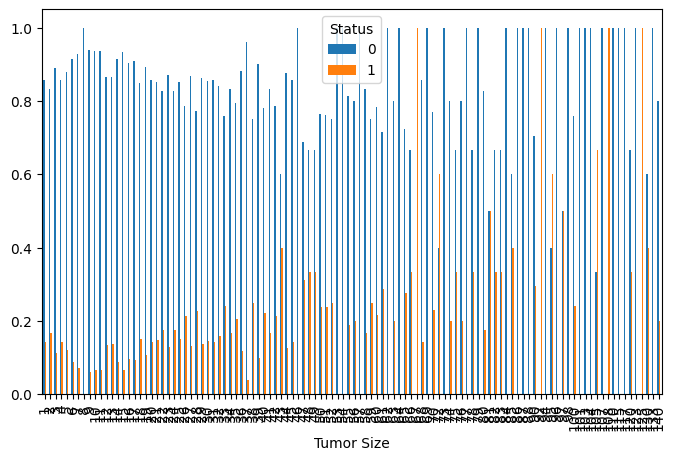

In [106]:
plot('Tumor Size')

<Axes: xlabel='Estrogen Status'>

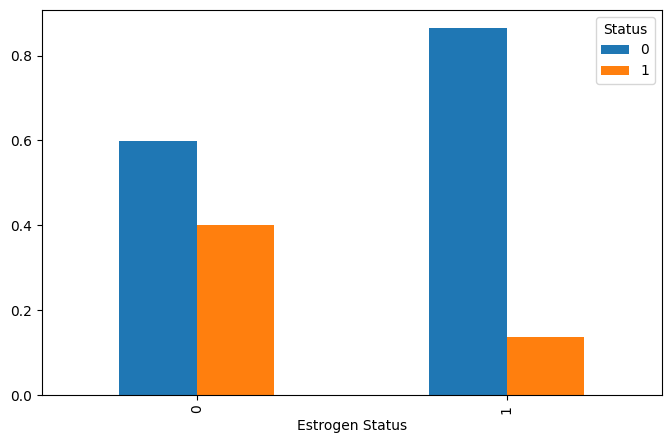

In [107]:
plot('Estrogen Status')

<Axes: xlabel='Progesterone Status'>

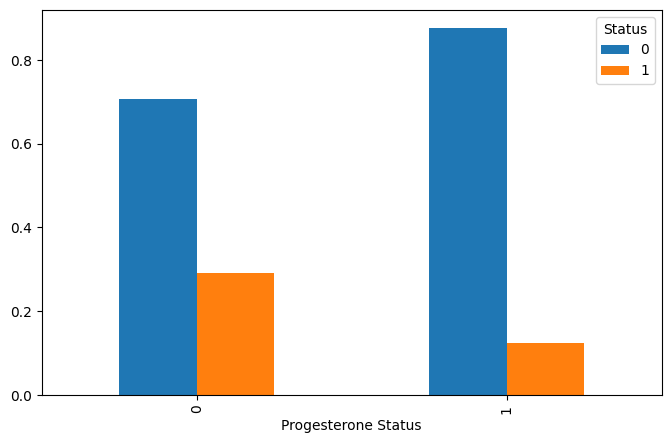

In [108]:
plot('Progesterone Status')

<Axes: xlabel='Regional Node Examined'>

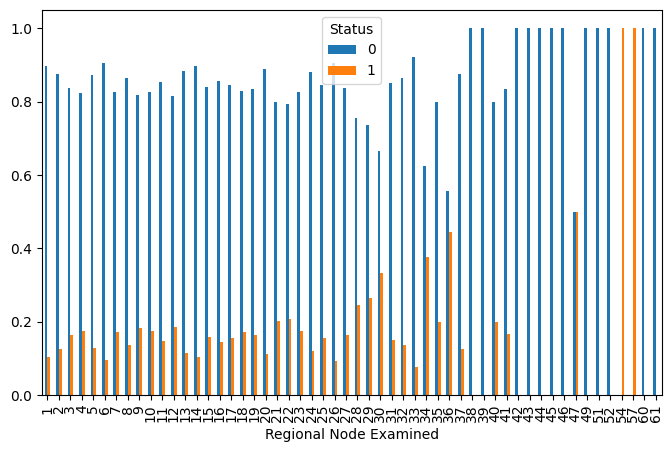

In [109]:
plot('Regional Node Examined')

<Axes: xlabel='Reginol Node Positive'>

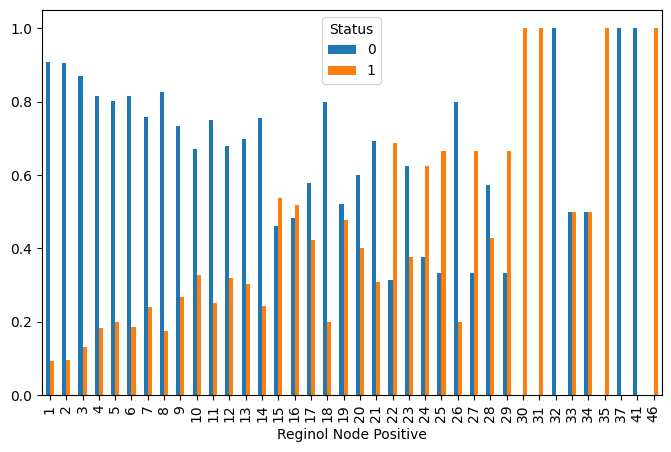

In [110]:
plot('Reginol Node Positive')

<Axes: xlabel='Survival Months'>

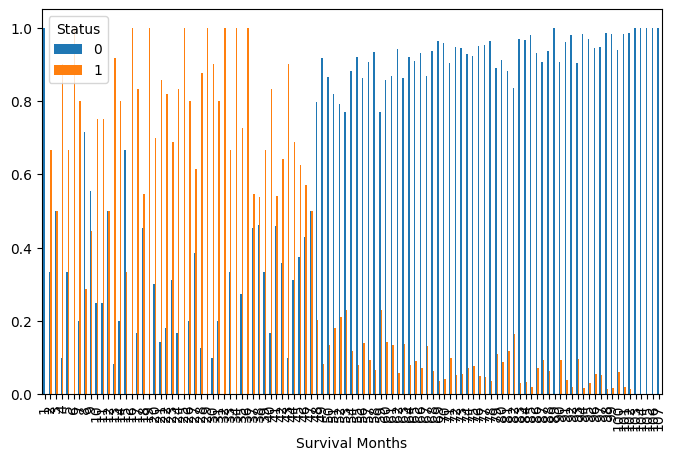

In [111]:
plot('Survival Months')

In [112]:
df_new=df.drop(columns=['Race','Age', 'Marital Status'])
df_new

,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,0,0,0,1,3,1,4,1,1,24,1,60,0
1,1,1,2,0,2,1,35,1,1,14,5,62,0
2,2,2,4,0,2,1,63,1,1,14,7,75,0
3,0,0,0,1,3,1,18,1,1,2,1,84,0
4,1,0,1,1,3,1,41,1,1,3,1,50,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4019,0,0,0,0,2,1,9,1,1,1,1,49,0
4020,1,1,2,0,2,1,46,1,1,14,8,69,0
4021,1,0,1,0,2,1,22,1,0,11,3,69,0
4022,1,0,1,0,2,1,44,1,1,11,1,72,0


**CORRELATION**

In [113]:
#Finding Correlation
cn=df_new.corr()
cn

,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
T Stage,1.000000,0.276903,0.606606,-0.031534,0.110183,-0.221114,0.809160,-0.060894,-0.057526,0.113955,0.242961,-0.085904,0.154615
N Stage,0.276903,1.000000,0.881879,-0.036360,0.148767,-0.260563,0.277832,-0.101959,-0.093658,0.328206,0.838058,-0.139696,0.255724
6th Stage,0.606606,0.881879,1.000000,-0.042471,0.169957,-0.291962,0.513901,-0.105560,-0.101143,0.317107,0.773944,-0.145038,0.257566
differentiate,-0.031534,-0.036360,-0.042471,1.000000,-0.365479,-0.008952,-0.028502,-0.021783,0.009035,-0.057366,-0.028446,-0.004613,-0.018586
Grade,0.110183,0.148767,0.169957,-0.365479,1.000000,-0.043694,0.099512,-0.186759,-0.175798,0.083417,0.122906,-0.058445,0.134152
A Stage,-0.221114,-0.260563,-0.291962,-0.008952,-0.043694,1.000000,-0.123865,0.065561,0.026513,-0.068989,-0.232837,0.070139,-0.096571
Tumor Size,0.809160,0.277832,0.513901,-0.028502,0.099512,-0.123865,1.000000,-0.059546,-0.069812,0.104258,0.242247,-0.087016,0.134147
Estrogen Status,-0.060894,-0.101959,-0.105560,-0.021783,-0.186759,0.065561,-0.059546,1.000000,0.513295,-0.044795,-0.085949,0.128522,-0.184628
Progesterone Status,-0.057526,-0.093658,-0.101143,0.009035,-0.175798,0.026513,-0.069812,0.513295,1.000000,-0.017977,-0.078004,0.096102,-0.177039
Regional Node Examined,0.113955,0.328206,0.317107,-0.057366,0.083417,-0.068989,0.104258,-0.044795,-0.017977,1.000000,0.411520,-0.022166,0.034705


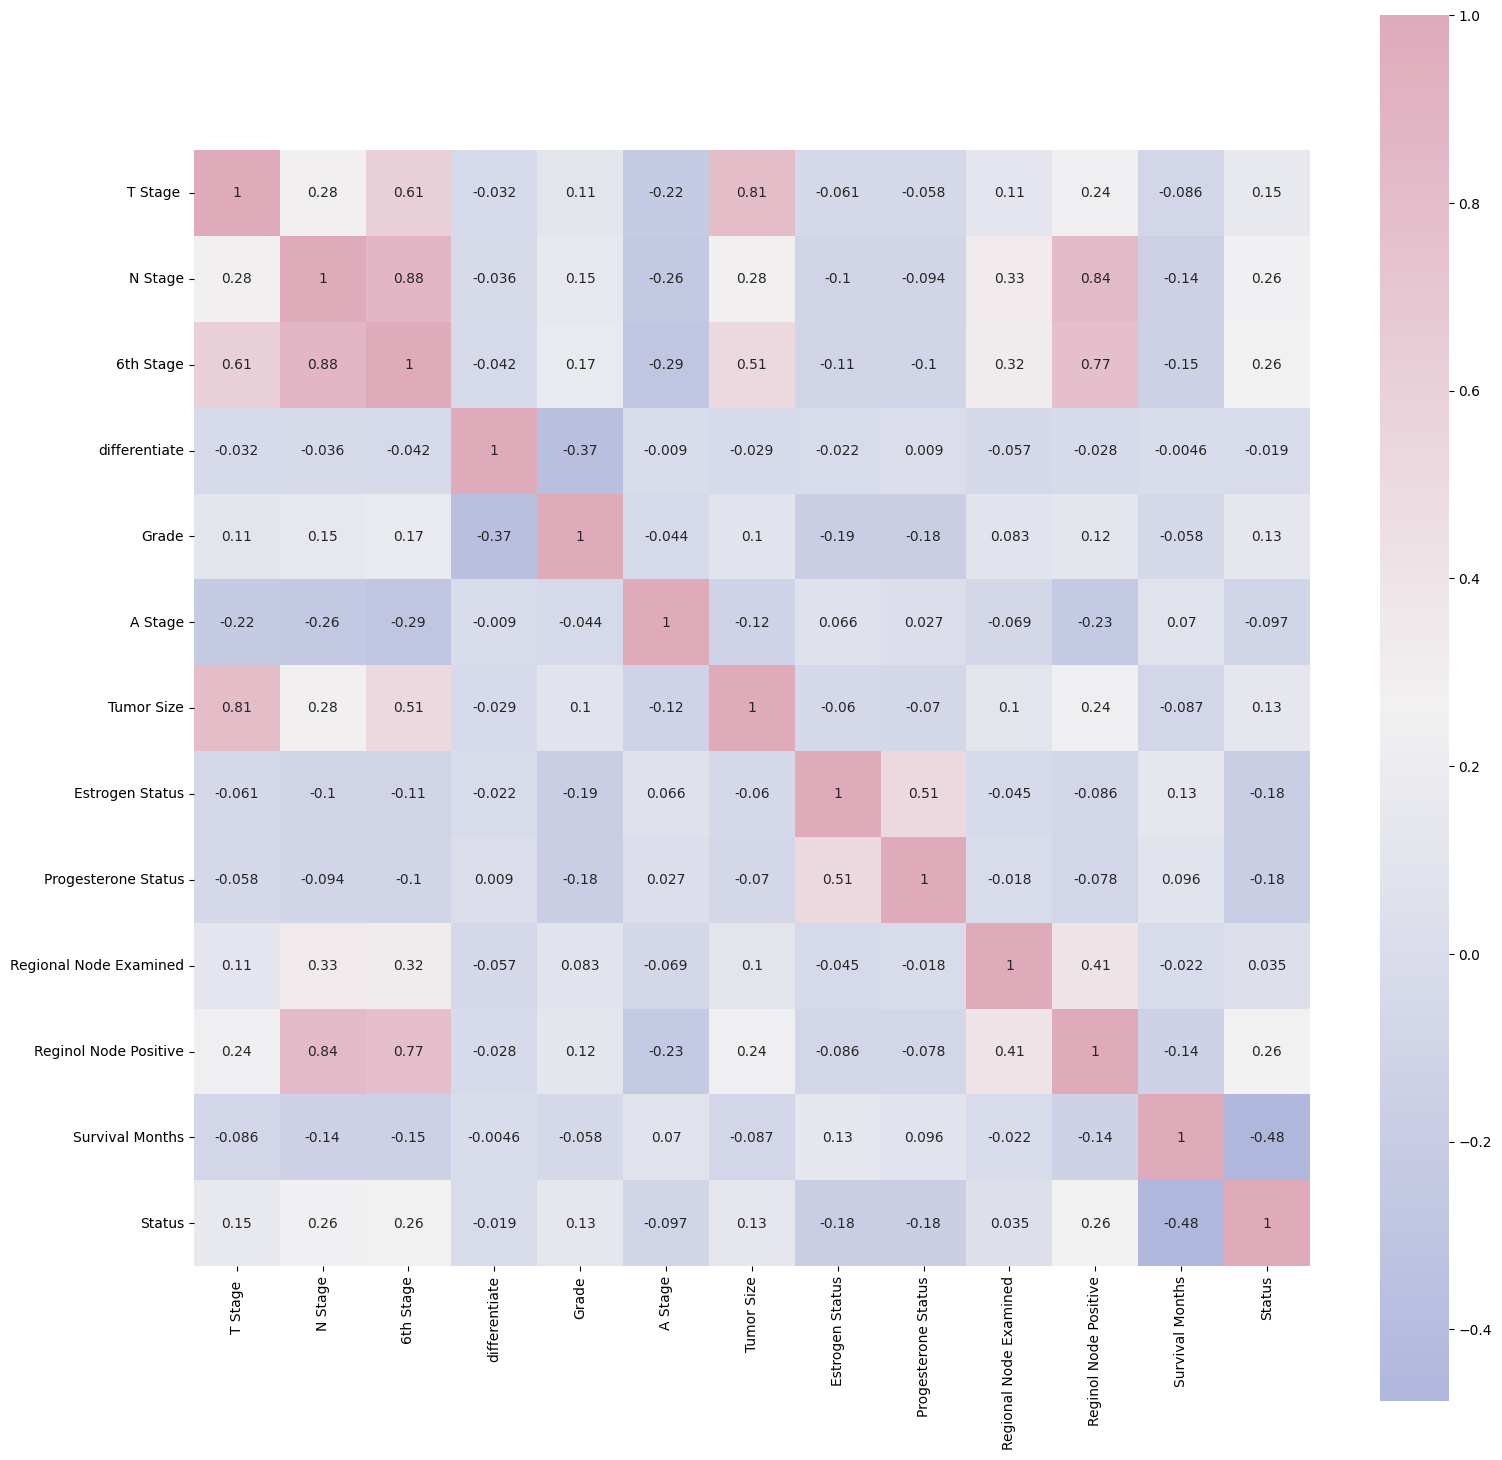

In [114]:
#Correlation
cmap=sns.diverging_palette(260,-10,s=50, l=75, n=6,
as_cmap=True)
plt.subplots(figsize=(18,18))
sns.heatmap(cn,cmap=cmap,annot=True, square=True)
plt.show()

<Axes: >

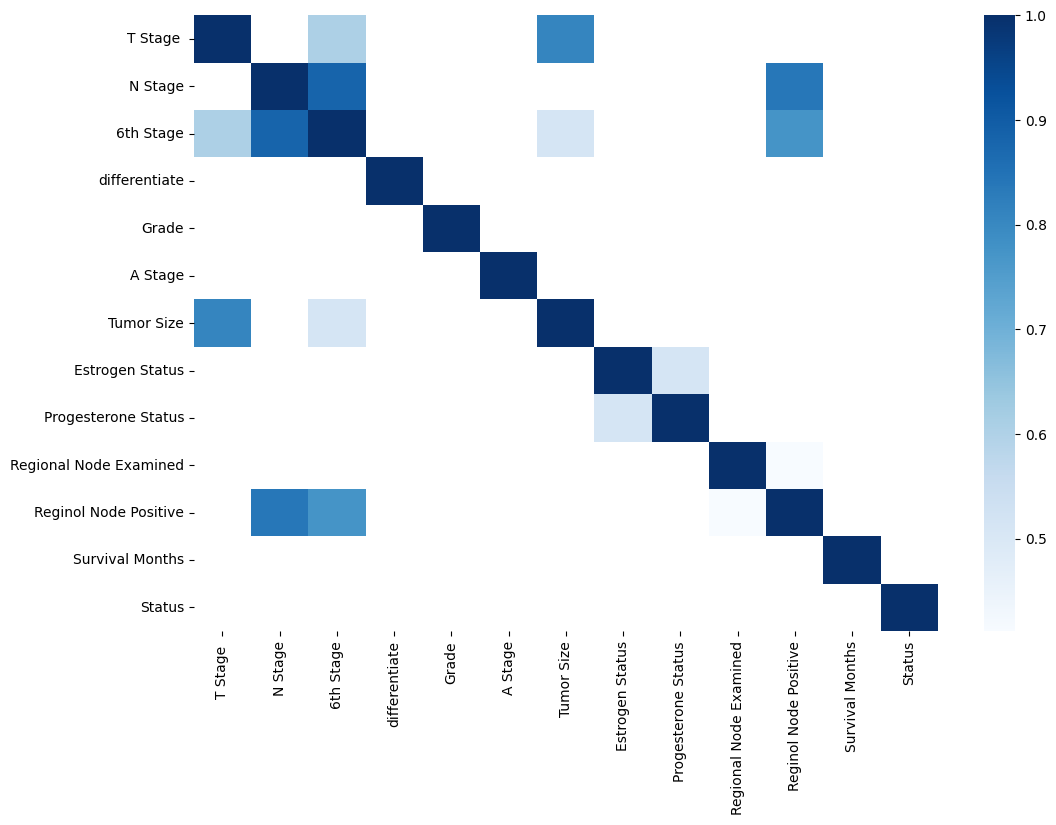

In [115]:
kot = cn[cn>=.40]
plt.figure(figsize=(12,8))
sns.heatmap(kot, cmap="Blues")

**Feature Engineering**

Feature Engineering is the process of creating new features using existing features.



The correlation matrix shows that Tumor Size and 6th Stage are correlated more than 50%. So, lets create a new feature combining them. There are a lot of examples but we'll just take this one.

In [116]:
df_new['T6']=df_new['Tumor Size']*df_new['6th Stage']
df_new

,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status,T6
0,0,0,0,1,3,1,4,1,1,24,1,60,0,0
1,1,1,2,0,2,1,35,1,1,14,5,62,0,70
2,2,2,4,0,2,1,63,1,1,14,7,75,0,252
3,0,0,0,1,3,1,18,1,1,2,1,84,0,0
4,1,0,1,1,3,1,41,1,1,3,1,50,0,41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4019,0,0,0,0,2,1,9,1,1,1,1,49,0,0
4020,1,1,2,0,2,1,46,1,1,14,8,69,0,92
4021,1,0,1,0,2,1,22,1,0,11,3,69,0,22
4022,1,0,1,0,2,1,44,1,1,11,1,72,0,44


In [117]:
#Splitting independent and dependent variables
X = df_new.drop('Status', axis = 1)
y = df_new['Status']

**Target Distribution Imbalance Handling**

In [118]:
from imblearn.over_sampling import ADASYN
adasyn = ADASYN(random_state=42)
X, y = adasyn.fit_resample(X, y)

In [119]:
len(X)

6847

**Logistic Regression**

In [120]:
#Splitting data for training and testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.25, random_state=0)

In [121]:
#Fitting training data to the model
from sklearn.linear_model import LogisticRegression
lr_model=LogisticRegression(random_state=0)
lr_model.fit(X_train, y_train)

LogisticRegression(random_state=0)

In [122]:
#Predicting result using testing data
y_lr_pred= lr_model.predict(X_test)
y_lr_pred

array([0, 0, 1, ..., 0, 0, 1])

In [123]:
#Model accuracy
from sklearn.metrics import classification_report, accuracy_score, f1_score
lr_cr=classification_report(y_test, y_lr_pred)
print(lr_cr)

              precision    recall  f1-score   support

           0       0.70      0.77      0.74       839
           1       0.76      0.69      0.72       873

    accuracy                           0.73      1712
   macro avg       0.73      0.73      0.73      1712
weighted avg       0.73      0.73      0.73      1712



This model is almost 73% accurate.

**Decision Tree**

In [124]:
#Fitting training data to the model
from sklearn.tree import DecisionTreeClassifier
dt_model= DecisionTreeClassifier(criterion='entropy', random_state=0)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [125]:
#Predicting result using testing data
y_dt_pred= dt_model.predict(X_test)
y_dt_pred

array([0, 1, 1, ..., 1, 0, 1])

In [126]:
#Model accuracy
dt_cr=classification_report(y_test, y_dt_pred)
print(dt_cr)

              precision    recall  f1-score   support

           0       0.86      0.81      0.83       839
           1       0.83      0.87      0.85       873

    accuracy                           0.84      1712
   macro avg       0.84      0.84      0.84      1712
weighted avg       0.84      0.84      0.84      1712



This model is accurate 84%

**K Nearest Neighbor**

In [127]:
#Fitting K-NN classifier to the training set
from sklearn.neighbors import KNeighborsClassifier
knn_model= KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2 )
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [128]:
#Predicting result using testing data
y_knn_pred= knn_model.predict(X_test)
y_knn_pred

array([0, 1, 1, ..., 1, 0, 1])

In [129]:
#Model accuracy
knn_cr=classification_report(y_test, y_knn_pred)
print(knn_cr)

              precision    recall  f1-score   support

           0       0.94      0.74      0.82       839
           1       0.79      0.95      0.86       873

    accuracy                           0.85      1712
   macro avg       0.86      0.84      0.84      1712
weighted avg       0.86      0.85      0.84      1712



This model is accurate 85%.

**Gaussian Naive Bayes**

In [130]:
#Fitting Gaussian Naive Bayes classifier to the training set
from sklearn.naive_bayes import GaussianNB
gnb_model = GaussianNB()
gnb_model.fit(X_train, y_train)

GaussianNB()

In [131]:
#Predicting result using testing data
y_gnb_pred= gnb_model.predict(X_test)
y_gnb_pred

array([1, 0, 0, ..., 0, 0, 1])

In [132]:
#Model accuracy
gnb_cr=classification_report(y_test, y_gnb_pred)
print(gnb_cr)

              precision    recall  f1-score   support

           0       0.64      0.81      0.72       839
           1       0.76      0.56      0.64       873

    accuracy                           0.68      1712
   macro avg       0.70      0.69      0.68      1712
weighted avg       0.70      0.68      0.68      1712



This model is accurate 68%.

**Multinomial Naive Bayes**

In [133]:
#Fitting Multinomial Naive Bayes classifier to the training set
from sklearn.naive_bayes import MultinomialNB
mnb_model = MultinomialNB()
mnb_model.fit(X_train, y_train)

MultinomialNB()

In [134]:
#Predicting result using testing data
y_mnb_pred= mnb_model.predict(X_test)
y_mnb_pred

array([1, 0, 0, ..., 0, 0, 1])

In [135]:
#Model accuracy
mnb_cr=classification_report(y_test, y_mnb_pred)
print(mnb_cr)

              precision    recall  f1-score   support

           0       0.58      0.76      0.66       839
           1       0.67      0.47      0.55       873

    accuracy                           0.61      1712
   macro avg       0.63      0.62      0.61      1712
weighted avg       0.63      0.61      0.61      1712



This model is accurate 61%.

**Support Vector Classifier**

In [136]:
#Fitting SVC to the training set
from sklearn.svm import SVC
svc_model = SVC()
svc_model.fit(X_train, y_train)

SVC()

In [137]:
#Predicting result using testing data
y_svc_pred= svc_model.predict(X_test)
y_svc_pred

array([1, 0, 1, ..., 0, 0, 1])

In [138]:
#Model accuracy
svc_cr=classification_report(y_test, y_svc_pred)
print(svc_cr)

              precision    recall  f1-score   support

           0       0.71      0.74      0.72       839
           1       0.74      0.70      0.72       873

    accuracy                           0.72      1712
   macro avg       0.72      0.72      0.72      1712
weighted avg       0.72      0.72      0.72      1712



This model is accurate 72%.

**Random Forest**

In [139]:
#Training
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

RandomForestClassifier()

In [140]:
#Predicting result using testing data
y_rf_pred= rf_model.predict(X_test)
y_rf_pred

array([0, 0, 1, ..., 1, 0, 1])

In [141]:
#Model accuracy
rf_cr=classification_report(y_test, y_rf_pred)
print(rf_cr)

              precision    recall  f1-score   support

           0       0.91      0.87      0.89       839
           1       0.88      0.92      0.90       873

    accuracy                           0.90      1712
   macro avg       0.90      0.90      0.90      1712
weighted avg       0.90      0.90      0.90      1712



This model is accurate 90%.

**XGBoost**

In [142]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier()
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [143]:
#Predicting result using testing data
y_xgb_pred= xgb_model.predict(X_test)
y_xgb_pred

array([0, 0, 1, ..., 1, 0, 1])

In [144]:
#Model accuracy
xgb_cr=classification_report(y_test, y_xgb_pred)
print(xgb_cr)

              precision    recall  f1-score   support

           0       0.90      0.88      0.89       839
           1       0.88      0.90      0.89       873

    accuracy                           0.89      1712
   macro avg       0.89      0.89      0.89      1712
weighted avg       0.89      0.89      0.89      1712



This model is accurate 89%.

**Multi-layer Perceptron classifier**

In [145]:
#Training a neural network model
from sklearn.neural_network import MLPClassifier
mlp_model = MLPClassifier()
mlp_model.fit(X_train, y_train)

MLPClassifier()

In [146]:
#Predicting result using testing data
y_mlp_pred= mlp_model.predict(X_test)
y_mlp_pred

array([0, 0, 1, ..., 1, 0, 1])

In [147]:
#Model accuracy
mlp_cr=classification_report(y_test, y_mlp_pred)
print(mlp_cr)

              precision    recall  f1-score   support

           0       0.80      0.67      0.73       839
           1       0.73      0.84      0.78       873

    accuracy                           0.76      1712
   macro avg       0.77      0.76      0.76      1712
weighted avg       0.76      0.76      0.76      1712



This model is accurate 77%.

**Gradient Boosting**

In [148]:
#Training
from sklearn.ensemble import GradientBoostingClassifier
gb_model = GradientBoostingClassifier()
gb_model.fit(X_train, y_train)

GradientBoostingClassifier()

In [149]:
#Predicting result using testing data
y_gb_pred= gb_model.predict(X_test)
y_gb_pred

array([0, 0, 1, ..., 0, 0, 1])

In [150]:
#Model accuracy
gb_cr=classification_report(y_test, y_gb_pred)
print(gb_cr)

              precision    recall  f1-score   support

           0       0.77      0.82      0.79       839
           1       0.82      0.76      0.79       873

    accuracy                           0.79      1712
   macro avg       0.79      0.79      0.79      1712
weighted avg       0.79      0.79      0.79      1712



This model is accurate 79%.

From the above calculated accuracies, it is clear that the Random Forest model performed atmost level while the worst performed one is Multinomial Naive Bayes.

**Cross Validation**

K-Fold cross validation is a popular technique used in machine learning for model evaluation and selection. It involves dividing a dataset into K subsets of equal size, called folds. The algorithm then trains and evaluates the model K times, each time using a different fold as the validation set and the remaining K-1 folds as the training set.

During each iteration of K-Fold cross validation, the model is trained on K-1 folds and evaluated on the remaining fold. The performance metrics are then averaged over all K iterations to obtain an estimate of the model's overall performance.

K-Fold cross validation is a robust method for model evaluation because it uses all the available data for training and testing. It also helps to reduce the risk of overfitting and provides a more accurate estimate of the model's performance than using a single training-test split.

Typically, values of K between 5 and 10 are used for K-Fold cross validation, but the optimal value of K may vary depending on the size and complexity of the dataset, as well as the type of model being evaluated.

In [151]:
# K-Fold Cross Validation

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

k = 10
kf = KFold(n_splits=k, shuffle=True, random_state=42)


# Logistic regerssion model
lr_model_scores = cross_val_score(lr_model,X, y, cv=kf)

# Decision tree model
dt_model_scores = cross_val_score(dt_model,X, y, cv=kf)

# KNN model
knn_model_scores = cross_val_score(knn_model,X, y, cv=kf)

# Gaussian naive bayes model
gnb_model_scores = cross_val_score(gnb_model,X, y, cv=kf)

# Multinomial naive bayes model
mnb_model_scores = cross_val_score(mnb_model,X, y, cv=kf)

# Support Vector Classifier model
svc_model_scores = cross_val_score(svc_model,X, y, cv=kf)

# Random forest model
rf_model_scores = cross_val_score(rf_model,X, y, cv=kf)

# XGBoost model
xgb_model_scores = cross_val_score(xgb_model,X, y, cv=kf)

# Multi-layer perceptron model
mlp_model_scores = cross_val_score(mlp_model,X, y, cv=kf)

# Gradient boost model
gb_model_scores = cross_val_score(gb_model,X, y, cv=kf)


print("Logistic regression models' average accuracy:", np.mean(lr_model_scores))
print("Decision tree models' average accuracy:", np.mean(dt_model_scores))
print("KNN models' average accuracy:", np.mean(knn_model_scores))
print("Gaussian naive bayes models' average accuracy:", np.mean(gnb_model_scores))
print("Multinomial naive bayes models' average accuracy:", np.mean(mnb_model_scores))
print("Support Vector Classifier models' average accuracy:", np.mean(svc_model_scores))
print("Random forest models' average accuracy:", np.mean(rf_model_scores))
print("XGBoost models' average accuracy:", np.mean(xgb_model_scores))
print("Multi-layer perceptron models' average accuracy:", np.mean(mlp_model_scores))
print("Gradient boost models' average accuracy:", np.mean(gb_model_scores))

Logistic regression models' average accuracy: 0.7238190976224016
Decision tree models' average accuracy: 0.8559886028940966
KNN models' average accuracy: 0.8444551158919197
Gaussian naive bayes models' average accuracy: 0.6778138472702439
Multinomial naive bayes models' average accuracy: 0.6202736159132625
Support Vector Classifier models' average accuracy: 0.7162250821701456
Random forest models' average accuracy: 0.9036048149571009
XGBoost models' average accuracy: 0.8873893370896827
Multi-layer perceptron models' average accuracy: 0.7587273231741153
Gradient boost models' average accuracy: 0.7924629700772614


So the Random Forest model gives the most accuracy of 90.3%, while Multinomial Naive Bayes model gives the least accuarcy of 62.02%.

In [152]:
# K-Fold Cross Validation

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

k = 10
kf = StratifiedKFold(n_splits=k)


# Logistic regerssion model
lr_model_scores = cross_val_score(lr_model,X, y, cv=kf)

# Decision tree model
dt_model_scores = cross_val_score(dt_model,X, y, cv=kf)

# KNN model
knn_model_scores = cross_val_score(knn_model,X, y, cv=kf)

# Gaussian naive bayes model
gnb_model_scores = cross_val_score(gnb_model,X, y, cv=kf)

# Multinomial naive bayes model
mnb_model_scores = cross_val_score(mnb_model,X, y, cv=kf)

# Support Vector Classifier model
svc_model_scores = cross_val_score(svc_model,X, y, cv=kf)

# Random forest model
rf_model_scores = cross_val_score(rf_model,X, y, cv=kf)

# XGBoost model
xgb_model_scores = cross_val_score(xgb_model,X, y, cv=kf)

# Multi-layer perceptron model
mlp_model_scores = cross_val_score(mlp_model,X, y, cv=kf)

# Gradient boost model
gb_model_scores = cross_val_score(gb_model,X, y, cv=kf)


print("Logistic regression models' average accuracy:", np.mean(lr_model_scores))
print("Decision tree models' average accuracy:", np.mean(dt_model_scores))
print("KNN models' average accuracy:", np.mean(knn_model_scores))
print("Gaussian naive bayes models' average accuracy:", np.mean(gnb_model_scores))
print("Multinomial naive bayes models' average accuracy:", np.mean(mnb_model_scores))
print("Support Vector Classifier models' average accuracy:", np.mean(svc_model_scores))
print("Random forest models' average accuracy:", np.mean(rf_model_scores))
print("XGBoost models' average accuracy:", np.mean(xgb_model_scores))
print("Multi-layer perceptron models' average accuracy:", np.mean(mlp_model_scores))
print("Gradient boost models' average accuracy:", np.mean(gb_model_scores))

Logistic regression models' average accuracy: 0.7220651385153882
Decision tree models' average accuracy: 0.8238669057070902
KNN models' average accuracy: 0.8196245784778249
Gaussian naive bayes models' average accuracy: 0.677083279976096
Multinomial naive bayes models' average accuracy: 0.619965211081231
Support Vector Classifier models' average accuracy: 0.7108210611687369
Random forest models' average accuracy: 0.8762967942971784
XGBoost models' average accuracy: 0.8630089213300891
Multi-layer perceptron models' average accuracy: 0.7507000469543689
Gradient boost models' average accuracy: 0.7752362658470994


So the Random forest models gives the most accuracy of 87.6%, and also other models like XGBoost gives almost same accuracies, while Multinomial Naive Bayes model gives the least accuarcy of 61.99%.